In [12]:
import pandas as pd
import numpy as np
import joblib
import time
import tracemalloc
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay)

os.makedirs('data', exist_ok=True)

# Regenerate fresh pkl files
df = pd.read_csv('../Data/group5-adult.csv')
df.replace('?', np.nan, inplace=True)
df['income'] = df['income'].str.strip()
df['income'] = (df['income'] == '>50K').astype(int)

numeric_cols     = ['age', 'fnlwgt', 'education-num',
                    'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'marital-status',
                    'occupation', 'relationship', 'race',
                    'sex', 'native-country']

X = df[numeric_cols + categorical_cols]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])
preprocessor.fit(X_train)

joblib.dump((X_train, X_test, y_train, y_test), 'data/train_test_split.pkl')
joblib.dump(preprocessor, 'data/preprocessor.pkl')

print("Data ready!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Data ready!
X_train: (23508, 14) | X_test: (5877, 14)


In [13]:
rf_baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

tracemalloc.start()
start = time.time()
rf_baseline.fit(X_train, y_train)
train_time = time.time() - start
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_pred = rf_baseline.predict(X_test)
y_prob = rf_baseline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("RANDOM FOREST — BASELINE PERFORMANCE")
print("=" * 55)
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Train Time: {train_time:.4f}s")
print(f"Peak Mem  : {peak / 1024:.2f} KB")
print("=" * 55)

RANDOM FOREST — BASELINE PERFORMANCE
Precision : 0.7315
Recall    : 0.6159
F1 Score  : 0.6687
ROC-AUC   : 0.9020
Train Time: 1.6177s
Peak Mem  : 39342.31 KB


In [14]:
param_grid = {
    'classifier__n_estimators'  : [50, 100],
    'classifier__max_depth'     : [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_rf_pipeline = grid.best_estimator_

print(f"Best Params: {grid.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


In [15]:
tracemalloc.start()
start = time.time()
best_rf_pipeline.fit(X_train, y_train)
train_time = time.time() - start
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_pred_best = best_rf_pipeline.predict(X_test)
y_prob_best = best_rf_pipeline.predict_proba(X_test)[:, 1]

start_pred = time.time()
_ = best_rf_pipeline.predict(X_test)
pred_time = time.time() - start_pred

print("=" * 55)
print("RANDOM FOREST — TUNED PERFORMANCE")
print("=" * 55)
print(classification_report(y_test, y_pred_best,
      target_names=['<=50K', '>50K']))
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"Train Time: {train_time:.4f}s")
print(f"Peak Mem  : {peak / 1024:.2f} KB")
print(f"Pred Time : {pred_time:.4f}s")
print("=" * 55)

RANDOM FOREST — TUNED PERFORMANCE
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4466
        >50K       0.75      0.62      0.68      1411

    accuracy                           0.86      5877
   macro avg       0.82      0.78      0.79      5877
weighted avg       0.85      0.86      0.85      5877

Accuracy  : 0.8589
ROC-AUC   : 0.9093
Train Time: 1.5432s
Peak Mem  : 39341.20 KB
Pred Time : 0.0628s


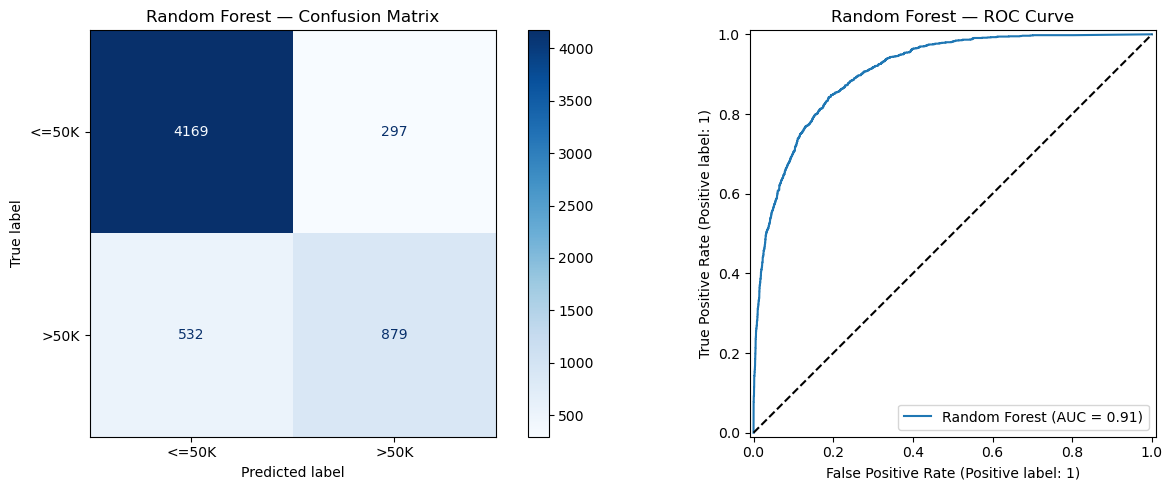

Plots saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    best_rf_pipeline, X_test, y_test,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Random Forest — Confusion Matrix')

RocCurveDisplay.from_estimator(
    best_rf_pipeline, X_test, y_test,
    ax=axes[1], name='Random Forest'
)
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('Random Forest — ROC Curve')

plt.tight_layout()
plt.savefig('data/rf_plots.png', dpi=150)
plt.show()
print("Plots saved!")

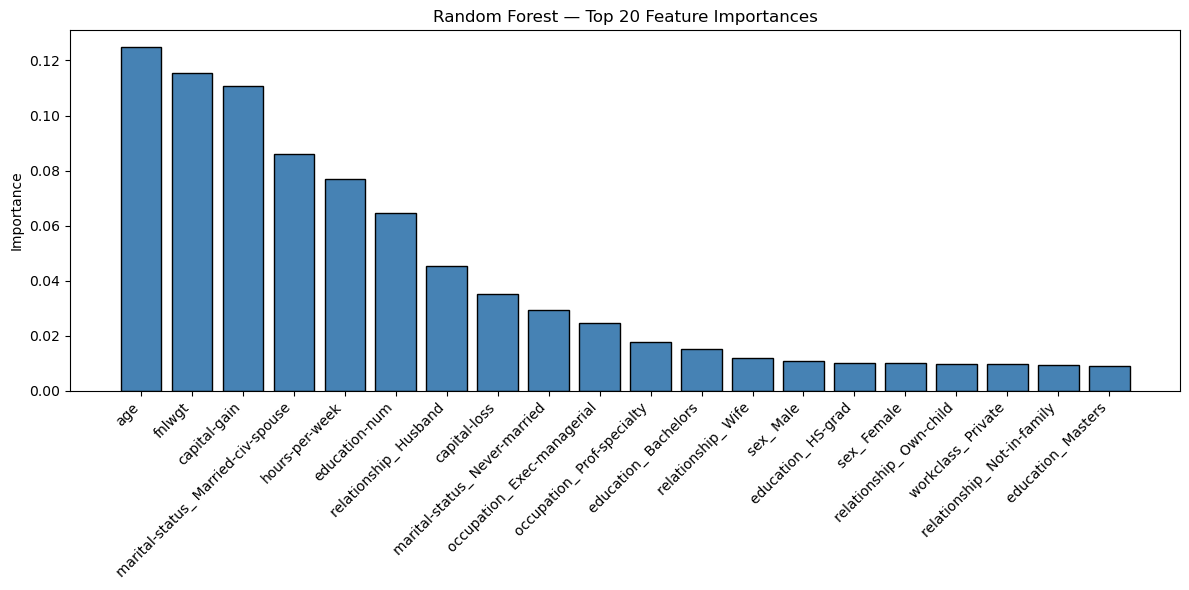

Feature importance saved!


In [17]:
# Get feature names
feature_names = (
    numeric_cols +
    list(preprocessor.named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_cols))
)

importances = best_rf_pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(20), importances[indices], color='steelblue', edgecolor='black')
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax.set_title('Random Forest — Top 20 Feature Importances')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('data/rf_feature_importance.png', dpi=150)
plt.show()
print("Feature importance saved!")

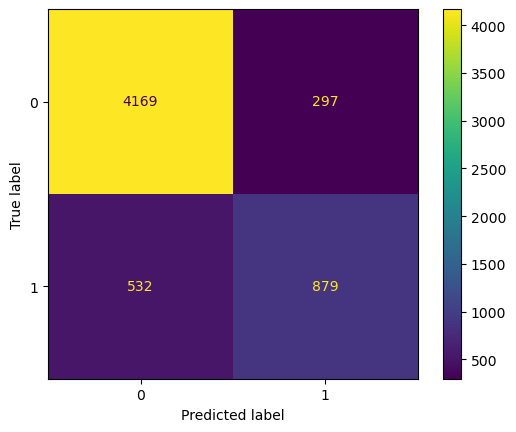

In [18]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [19]:
joblib.dump(best_rf_pipeline, 'data/rf_model.pkl')

rf_results = {
    'model_name'  : 'Random Forest',
    'accuracy'    : round(accuracy_score(y_test, y_pred_best), 4),
    'roc_auc'     : round(roc_auc_score(y_test, y_prob_best), 4),
    'train_time'  : round(train_time, 4),
    'peak_mem_kb' : round(peak / 1024, 2),
    'pred_time'   : round(pred_time, 4)
}

joblib.dump(rf_results, 'data/rf_results.pkl')
print("RF model and results saved!")
print(rf_results)

RF model and results saved!
{'model_name': 'Random Forest', 'accuracy': 0.8589, 'roc_auc': np.float64(0.9093), 'train_time': 1.5432, 'peak_mem_kb': 39341.2, 'pred_time': 0.0628}
